## Load the processed data

In [10]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight

# load processed data
X = np.load("../Data/processed/X.npy")
y = np.load("../Data/processed/y.npy")

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (101163, 250)
Shape of y: (101163,)


## Map labels to human-readable names

In [11]:
label_map = {
    0: "N (Normal)",
    1: "S (Supraventricular)",
    2: "V (Ventricular)",
    3: "Q (Other)"
}

## Visualize class imbalance

Class distribution: Counter({0: 90347, 2: 7235, 1: 2779, 3: 802})


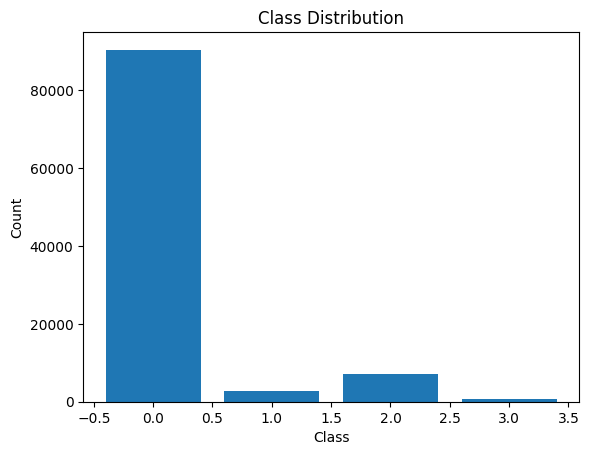

In [2]:
label_counts = Counter(y)

print("Class distribution:", label_counts)

plt.bar(label_counts.keys(), label_counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Example ECG beats per class

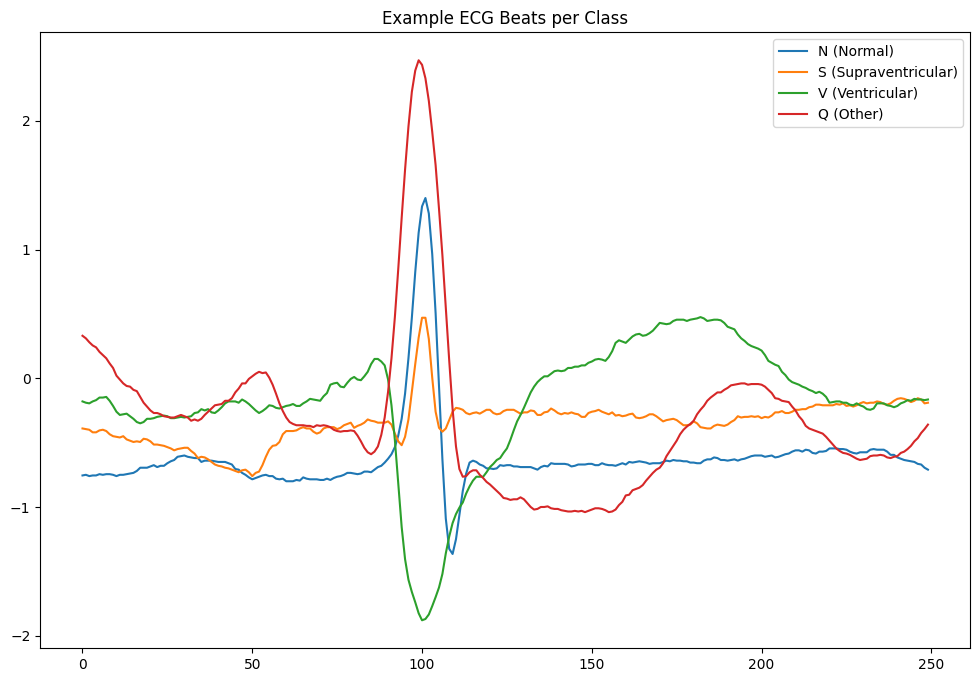

In [4]:
import random

plt.figure(figsize=(12, 8))

for cls in np.unique(y):
    idx = np.where(y == cls)[0]
    sample_idx = random.choice(idx)
    
    plt.plot(X[sample_idx], label=label_map[cls])

plt.legend()
plt.title("Example ECG Beats per Class")
plt.show()

## Check signal quality / noise

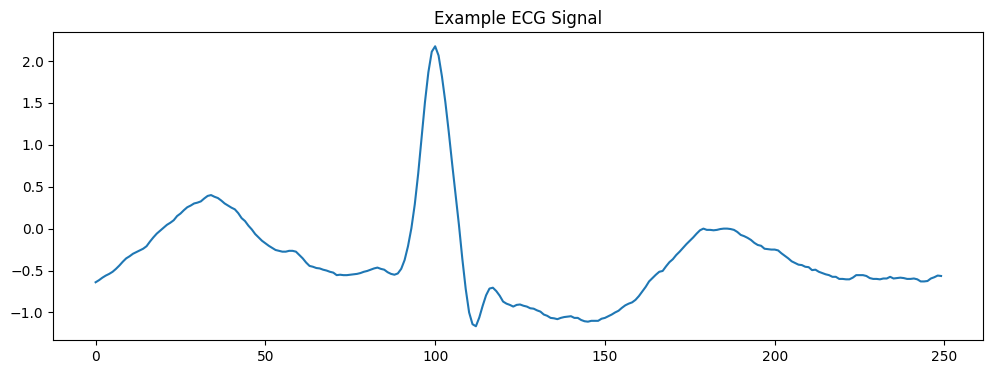

In [5]:
plt.figure(figsize=(12,4))
plt.plot(X[0])
plt.title("Example ECG Signal")
plt.show()

## Compute class weights

In [6]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)

class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {0: 0.2799290513243384, 1: 9.100665707088881, 2: 3.495611610228058, 3: 31.534600997506235}


In [8]:
counts  = Counter(y)
total   = len(y)
classes = sorted(counts.keys())
labels  = [label_map[c] for c in classes]
values  = [counts[c]    for c in classes]
ratios  = [counts[c] / total * 100 for c in classes]

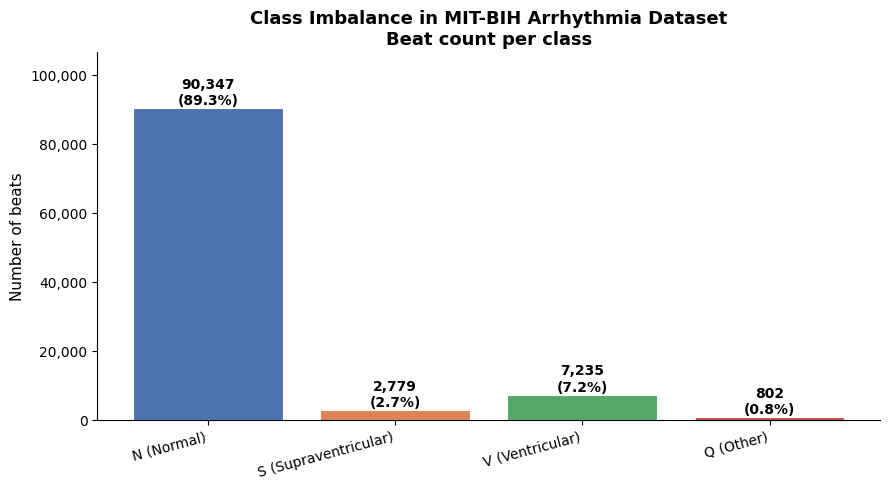

In [ ]:
# Bar chart — absolute counts ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=0.8)

ax.set_title('Class Imbalance in MIT-BIH Arrhythmia Dataset\nBeat count per class',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of beats', fontsize=11)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=10)

for bar, v, r in zip(bars, values, ratios):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.003,
        f'{v:,}\n({r:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylim(0, max(values) * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [15]:
print(f"""
Key findings:
  - Normal (N) beats account for {counts[0]/total*100:.1f}% of the dataset.
  - The most severe minority class is '{label_map[minority_cls]}' with only {minority_count:,} beats.
  - Imbalance ratio (N vs smallest class): {ratio:.1f}:1

Why this matters:
  A naive model that always predicts 'Normal' would achieve ~{counts[0]/total*100:.0f}% accuracy,
  which is misleading. Rare classes (S, V, Q) are clinically the most critical to detect, 
  especially 'V (Ventricular)' which can indicate life-threatening arrhythmias. Thus,
  missing a ventricular arrhythmia is a patient-safety issue.

Mitigation strategies used in this project:
  1. Class weights   : {{{', '.join([f'{c}: {class_weights[c]:.2f}' for c in classes])}}}
     Pass to model  : model.fit(..., class_weight=class_weights)
  2. SMOTE oversampling : synthetically generates minority-class beats in feature space.
     Use AFTER train/test split and ONLY on the training set to avoid data leakage.
  3. Evaluation metric  : report F1-score (macro) and confusion matrix,
     NOT accuracy, as the primary benchmark.
""")


Key findings:
  - Normal (N) beats account for 89.3% of the dataset.
  - The most severe minority class is 'Q (Other)' with only 802 beats.
  - Imbalance ratio (N vs smallest class): 112.7:1

Why this matters:
  A naive model that always predicts 'Normal' would achieve ~89% accuracy,
  which is misleading. Rare classes (S, V, Q) are clinically the most critical to detect, 
  especially 'V (Ventricular)' which can indicate life-threatening arrhythmias. Thus,
  missing a ventricular arrhythmia is a patient-safety issue.

Mitigation strategies used in this project:
  1. Class weights   : {0: 0.28, 1: 9.10, 2: 3.50, 3: 31.53}
     Pass to model  : model.fit(..., class_weight=class_weights)
  2. SMOTE oversampling : synthetically generates minority-class beats in feature space.
     Use AFTER train/test split and ONLY on the training set to avoid data leakage.
  3. Evaluation metric  : report F1-score (macro) and confusion matrix,
     NOT accuracy, as the primary benchmark.

